<a href="https://colab.research.google.com/github/jcarrillosanroman08/ACTIVIDAD-FUNDAMENTAL/blob/main/EJERCICIOS2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ACTIVIDAD FUNDAMENAL JOSE ALFREDO CARRILLO SANROMAN 2000403
# FECHA DE ENTREGA 21/04/2026
#PROGRAMACION PARA INTELIGENCIA ARTIFICIAL

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

In [11]:
print("Valores NaN por columna antes de la eliminación:")
print(df.isnull().sum())

Valores NaN por columna antes de la eliminación:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [12]:
critical_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
rows_with_nan_in_critical = df[df[critical_columns].isnull().any(axis=1)]
print(f"\nNúmero de filas con NaN en columnas críticas: {len(rows_with_nan_in_critical)}")


Número de filas con NaN en columnas críticas: 2


In [15]:
average_body_mass = df.groupby(['species', 'island'])['body_mass_g'].mean().reset_index()
print("Masa  promedio por especie y por isla:")
display(average_body_mass)

Masa  promedio por especie y por isla:


,species,island,body_mass_g
0,Adelie,Biscoe,3709.659091
1,Adelie,Dream,3688.392857
2,Adelie,Torgersen,3706.372549
3,Chinstrap,Dream,3733.088235
4,Gentoo,Biscoe,5076.016260


In [16]:
gentoo_heavy_penguins = df[(df['species'] == 'Gentoo') & (df['body_mass_g'] > 5000)]
print("Pingüinos 'Gentoo' con masa corporal mayor a 5000g:")
display(gentoo_heavy_penguins.head())
print(f"\nNúmero de pingüinos 'Gentoo' que pesan más de 5000g: {gentoo_heavy_penguins.shape[0]}")

Pingüinos 'Gentoo' con masa corporal mayor a 5000g:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,MALE
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,MALE
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,MALE
227,Gentoo,Biscoe,46.7,15.3,219.0,5200.0,MALE
229,Gentoo,Biscoe,46.8,15.4,215.0,5150.0,MALE



Número de pingüinos 'Gentoo' que pesan más de 5000g: 61


In [22]:
#EJERCICIOS 2.2
bill_dimensions_df = df[['bill_length_mm', 'bill_depth_mm']]
print("Primeros 5 registros de la matriz NumPy:")
bill_dimensions_np = bill_dimensions_df.values
print("Primeros 5 registros de la matriz NumPy:")
print(bill_dimensions_np[:5])
print(f"\nForma de la matriz NumPy: {bill_dimensions_np.shape}")

Primeros 5 registros de la matriz NumPy:
Primeros 5 registros de la matriz NumPy:
[[39.1 18.7]
 [39.5 17.4]
 [40.3 18. ]
 [ nan  nan]
 [36.7 19.3]]

Forma de la matriz NumPy: (344, 2)


In [23]:
bill_proportion_np = bill_dimensions_np[:, 0] / bill_dimensions_np[:, 1]

print("Primeros 5 registros del array de proporciones:")
print(bill_proportion_np[:5])
print(f"\nForma del array de proporciones: {bill_proportion_np.shape}")

Primeros 5 registros del array de proporciones:
[2.09090909 2.27011494 2.23888889        nan 1.9015544 ]

Forma del array de proporciones: (344,)


In [24]:
bill_length = df['bill_length_mm'].values
mean_bill_length = np.mean(bill_length)
std_bill_length = np.std(bill_length)
upper_bound = mean_bill_length + 2 * std_bill_length
lower_bound = mean_bill_length - 2 * std_bill_length
outlier_indices = np.where((bill_length > upper_bound) | (bill_length < lower_bound)) # Aquí el símbolo "|" significa "or"
outlier_penguins = df.iloc[outlier_indices]
print(f"Media del largo del pico: {mean_bill_length:.2f} mm")
print(f"Desviación estándar del largo del pico: {std_bill_length:.2f} mm")
print(f"Límite superior (media + 2*std): {upper_bound:.2f} mm")
print(f"Límite inferior (media - 2*std): {lower_bound:.2f} mm")

print(f"\nNúmero de pingüinos con largo de pico a más de 2 desviaciones estándar: {len(outlier_penguins)}")
print("\nPingüinos considerados outliers por el largo del pico:")
display(outlier_penguins)

Media del largo del pico: nan mm
Desviación estándar del largo del pico: nan mm
Límite superior (media + 2*std): nan mm
Límite inferior (media - 2*std): nan mm

Número de pingüinos con largo de pico a más de 2 desviaciones estándar: 0

Pingüinos considerados outliers por el largo del pico:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex


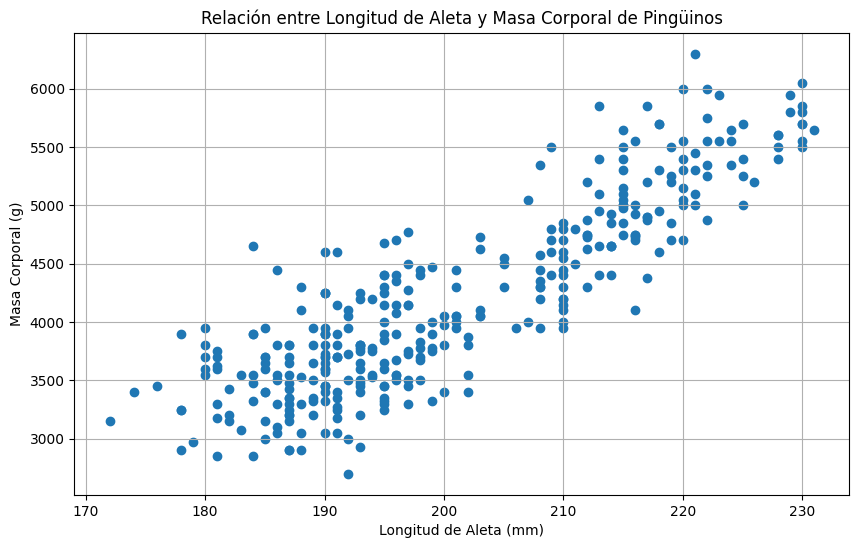

In [25]:
#EJERCICIO 2.2
plt.figure(figsize=(10, 6))
plt.scatter(df['flipper_length_mm'], df['body_mass_g'])
plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')
plt.title('Relación entre Longitud de Aleta y Masa Corporal de Pingüinos')
plt.grid(True)
plt.show()

/tmp/ipykernel_2596/4144663848.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(species_list))


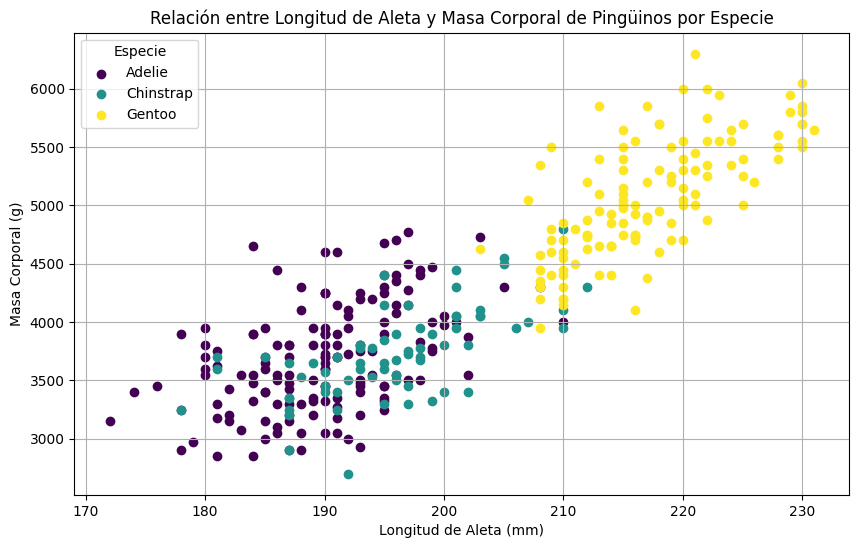

In [26]:
plt.figure(figsize=(10, 6))

# Obtener las especies únicas para asignar colores
species_list = df['species'].unique()
colors = plt.cm.get_cmap('viridis', len(species_list))

for i, species in enumerate(species_list):
    subset = df[df['species'] == species]
    plt.scatter(subset['flipper_length_mm'], subset['body_mass_g'],
                color=colors(i), label=species)

plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')
plt.title('Relación entre Longitud de Aleta y Masa Corporal de Pingüinos por Especie')
plt.grid(True)
plt.legend(title='Especie')
plt.show()

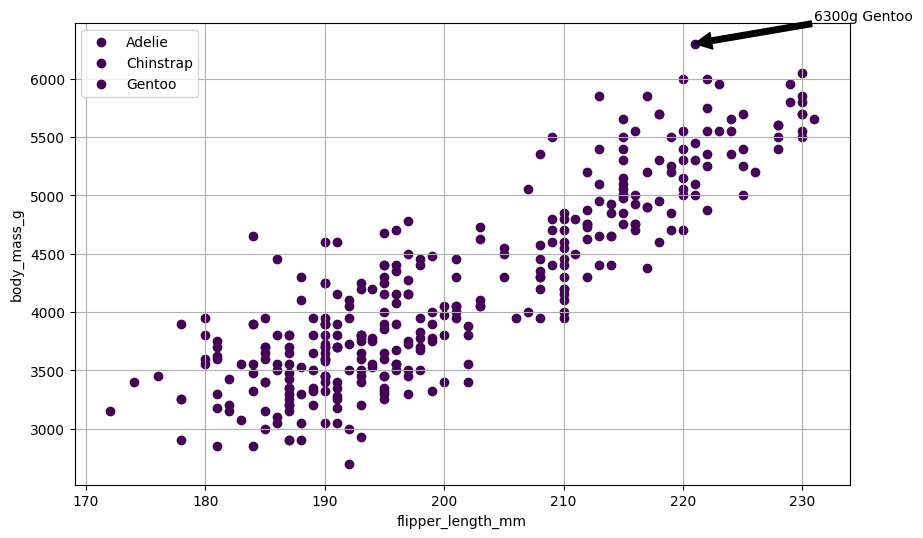

In [27]:
import matplotlib.pyplot as plt

df = df.dropna()

fila = df.loc[df['body_mass_g'].idxmax()]

x = fila['flipper_length_mm']
y = fila['body_mass_g']
esp = fila['species']

plt.figure(figsize=(10,6))

lista = df['species'].unique()
colores = plt.cm.viridis(range(len(lista)))

for i in range(len(lista)):
    parte = df[df['species'] == lista[i]]
    plt.scatter(parte['flipper_length_mm'], parte['body_mass_g'], color=colores[i], label=lista[i])

plt.annotate(f'{y:.0f}g {esp}',
             xy=(x,y),
             xytext=(x+10,y+200),
             arrowprops=dict(facecolor='black'))

plt.xlabel('flipper_length_mm')
plt.ylabel('body_mass_g')
plt.legend()
plt.grid()

plt.show()

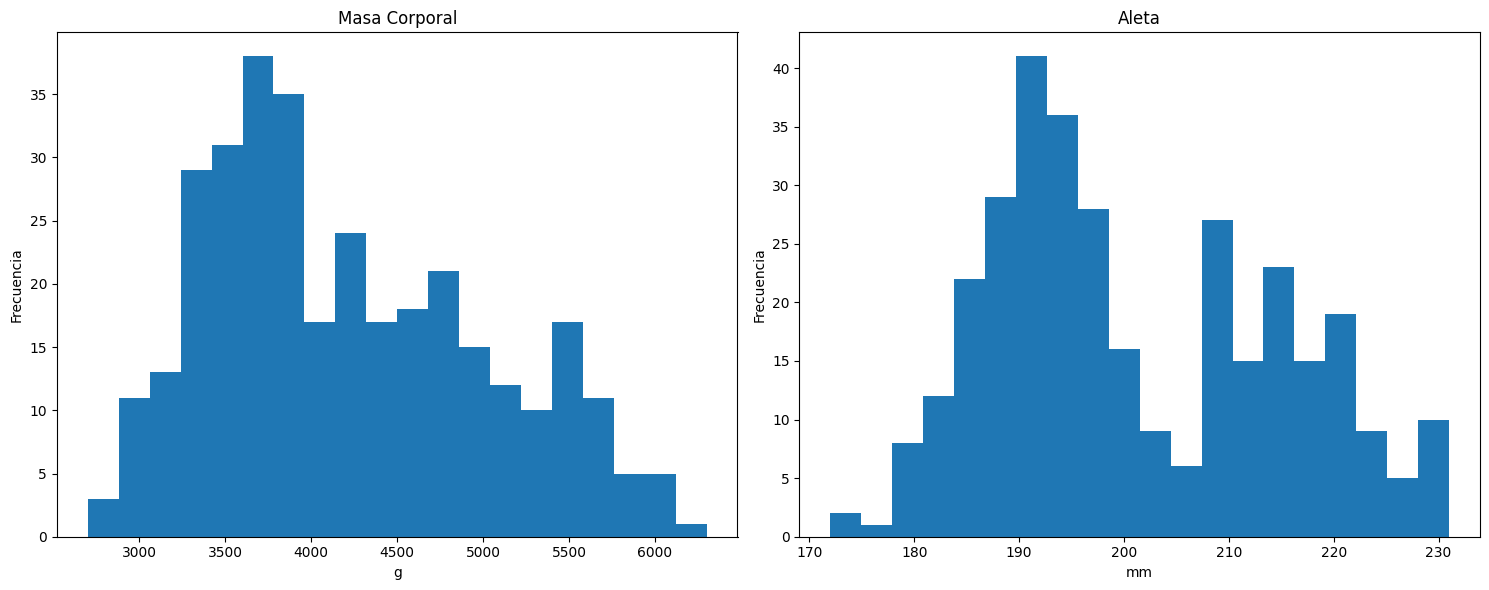

In [28]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

ax[0].hist(df['body_mass_g'].dropna(), bins=20)
ax[0].set_title('Masa Corporal')
ax[0].set_xlabel('g')
ax[0].set_ylabel('Frecuencia')

ax[1].hist(df['flipper_length_mm'].dropna(), bins=20)
ax[1].set_title('Aleta')
ax[1].set_xlabel('mm')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
#FIN